# Grad-CAM cho DeiT (theo notebook author)
Dùng `pytorch-grad-cam` + `reshape_transform` cho ViT.
Lưu ý: Grad-CAM ở đây chạy trên **một slice** (không phải toàn bộ subject).

In [1]:
cd ..

/data_hdd_16t/duydang/reze/3D-Unet


In [2]:
from pathlib import Path
import sys
import os

import torch
import torchvision.transforms as T
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import numpy as np


# Repo path
repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.train_2d import (
    MRIVolumeStackDataset,
    get_subject_split_stacks,
)
from src.baseline.models.deit2d_classifier import DeiT2DClassifier

config_path = "configs/baseline/train_2d_jpg.yaml"
cfg = OmegaConf.load(config_path)

# Force DeiT config and dataset paths
cfg.model.name = 'deit_base_patch16_224.fb_in1k'
cfg.model.pretrained = True
cfg.data.root_dir = "data/ADNI/jpg"
cfg.data.classes = ['AD', 'CN', 'MCI']

ckpt_path = "checkpoints/deit2d_attn_16sl/deit2d/deit2d-epoch=075.ckpt"
output_dir = Path('outputs/gradcam_deit2d')
output_dir.mkdir(parents=True, exist_ok=True)

print('Checkpoint:', ckpt_path)
print('Output dir:', output_dir)


Checkpoint: checkpoints/deit2d_attn_16sl/deit2d/deit2d-epoch=075.ckpt
Output dir: outputs/gradcam_deit2d


In [3]:
val_transform = T.Compose([
    T.Resize((cfg.data.image_size, cfg.data.image_size)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_subjects, val_subjects = get_subject_split_stacks(
    cfg.data.root_dir,
    list(cfg.data.classes),
    cfg.data.test_size,
)

val_ds = MRIVolumeStackDataset(
    val_subjects,
    num_slices=cfg.data.num_slices,
    strategy=cfg.data.val_strategy,
    transform=val_transform,
)

val_loader = torch.utils.data.DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print('Val subjects:', len(val_ds))


Val subjects: 300


In [4]:
# Load model directly (no Lightning)
device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
model = DeiT2DClassifier(
    timm_name=cfg.model.name,
    pretrained=False,
    image_size=cfg.data.image_size,
    in_channels=3,
    num_classes=cfg.model.num_classes,
    drop_path_rate=cfg.model.drop_path_rate,
    attn_drop_rate=cfg.model.attn_drop_rate,
    dropout=0.1,
)
ckpt = torch.load(ckpt_path, map_location='cpu')
state = ckpt.get('state_dict', ckpt)
state = {k.replace('model.', ''): v for k, v in state.items()}
missing, unexpected = model.load_state_dict(state, strict=False)
print('Missing:', missing)
print('Unexpected:', unexpected)
model.to(device)
model.eval()


Missing: []
Unexpected: []


DeiT2DClassifier(
  (encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.1, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
      

Pred class: MCI
Top slices: [8 0 3 5 6 2]
Saved: outputs/gradcam_deit2d/attention_weights.png
Saved: outputs/gradcam_deit2d/attention_top_slices.png


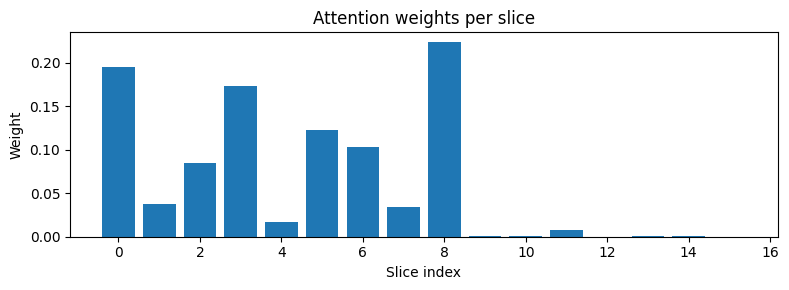

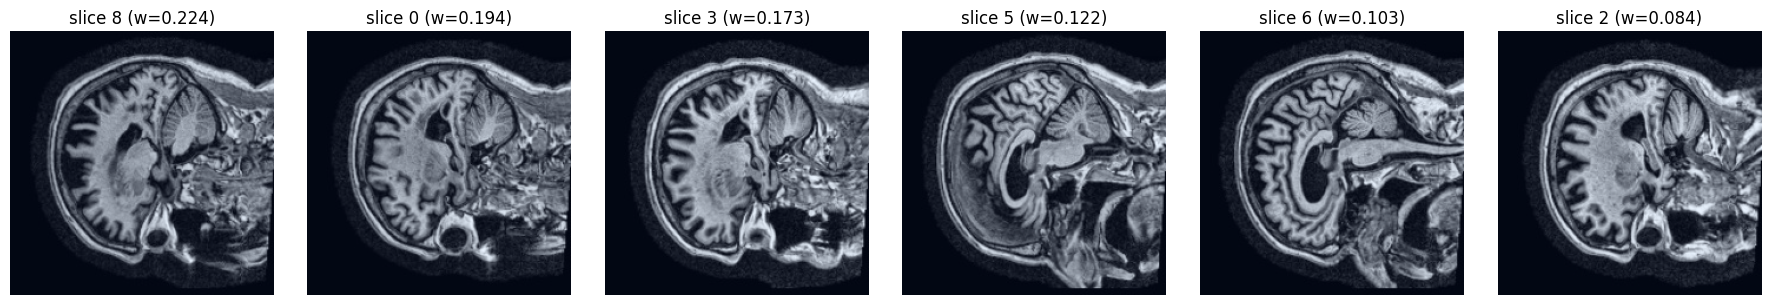

In [5]:
# Lấy 1 subject AD, xem attention weight theo slice
ad_index = cfg.data.classes.index('AD')
ad_batch = None
for xb, yb in val_loader:
    if int(yb.item()) == ad_index:
        ad_batch = (xb, yb)
        break
if ad_batch is None:
    raise RuntimeError('Không tìm thấy subject lớp AD trong val_loader')
x, y = ad_batch
x = x.to(device)

with torch.no_grad():
    logits = model(x)
pred_class = int(logits.argmax(dim=1).item())
print('Pred class:', cfg.data.classes[pred_class])

# Tính attention weights theo slice
b, s, c, h, w = x.shape
x_flat = x.view(b * s, c, h, w)
feats = model.encoder(x_flat)  # (B*S, D)
feats = feats.view(b, s, -1)
weights = model.pool.attn(feats)
weights = torch.softmax(weights, dim=1)[0, :, 0].detach().cpu().numpy()

# Top-k slices by attention
k = min(6, s)
top_idx = weights.argsort()[::-1][:k]
print('Top slices:', top_idx)

# Bar plot weights
plt.figure(figsize=(8, 3))
plt.bar(range(s), weights)
plt.title('Attention weights per slice')
plt.xlabel('Slice index')
plt.ylabel('Weight')
plt.tight_layout()
bar_path = output_dir / 'attention_weights.png'
plt.savefig(bar_path, dpi=150)
print('Saved:', bar_path)

# Show top-k slices
fig, axes = plt.subplots(1, k, figsize=(3*k, 3))
if k == 1:
    axes = [axes]
for ax, idx in zip(axes, top_idx):
    img = x[0, idx].detach().cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img)
    ax.set_title(f'slice {idx} (w={weights[idx]:.3f})')
    ax.axis('off')
plt.tight_layout()
grid_path = output_dir / 'attention_top_slices.png'
plt.savefig(grid_path, dpi=150)
print('Saved:', grid_path)


Max-attn slice: 8 weight: 0.2235361784696579


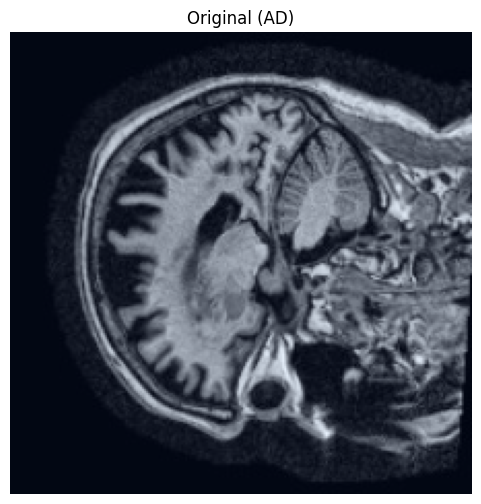

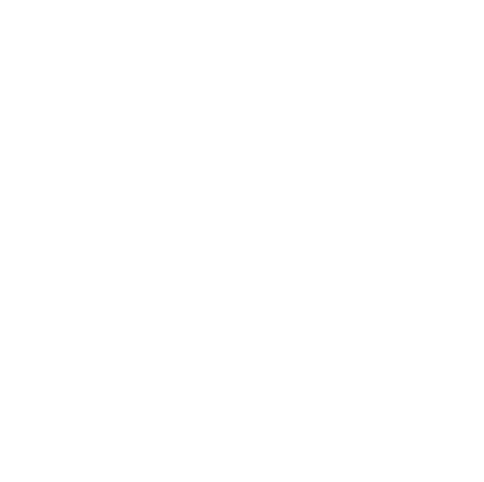

Saved: outputs/gradcam_deit2d/gradcam_AD_maxattn_slice.png


: 

In [ ]:
ad_index = cfg.data.classes.index('AD')
ad_batch = None
for xb, yb in val_loader:
    if int(yb.item()) == ad_index:
        ad_batch = (xb, yb)
        break
if ad_batch is None:
    raise RuntimeError('Không tìm thấy subject lớp AD trong val_loader')
x, y = ad_batch
x = x.to(device)

# full model prediction (uses attention pooling)
with torch.no_grad():
    logits = model(x)
pred_class = int(logits.argmax(dim=1).item())

# Tính attention weights theo slice
b, s, c, h, w = x.shape
x_flat = x.view(b * s, c, h, w)
feats = model.encoder(x_flat)  # (B*S, D)
feats = feats.view(b, s, -1)
weights = model.pool.attn(feats)
weights = torch.softmax(weights, dim=1)  # (B, S, 1)
slice_idx = int(weights[0, :, 0].argmax().item())
print('Max-attn slice:', slice_idx, 'weight:', float(weights[0, slice_idx, 0]))

img_tensor = x[:, slice_idx]  # (B, C, H, W)

img_raw = img_tensor[0].detach().cpu().permute(1, 2, 0).numpy()
img_norm = (img_raw - img_raw.min()) / (img_raw.max() - img_raw.min() + 1e-8)

plt.figure(figsize=(6, 6))
plt.imshow(img_norm)
plt.title('Original (AD)')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.axis('off')
out_path = output_dir / 'gradcam_AD_maxattn_slice.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out_path)
